In [330]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,f1_score, precision_score, recall_score, confusion_matrix, roc_curve, roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt

In [331]:
raw_data = pd.read_csv("./survey lung cancer.csv")
raw_data

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,F,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,M,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,M,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,M,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES


In [332]:
raw_data.isna().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [333]:
# raw_data['GENDER'] = raw_data['GENDER'].map({'M': 0, 'F': 1})
# raw_data['LUNG_CANCER'] = raw_data['LUNG_CANCER'].map({'NO': 0, 'YES': 1})
# raw_data

ord_enc = OrdinalEncoder(dtype= np.int32)
raw_data["GENDER"] = ord_enc.fit_transform(raw_data[["GENDER"]])
ord_enc = OrdinalEncoder(dtype= np.int32)
raw_data["LUNG_CANCER"] = ord_enc.fit_transform(raw_data[["LUNG_CANCER"]])
raw_data



,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0,56,1,1,1,2,2,2,1,1,2,2,2,2,1,1
305,1,70,2,1,1,1,1,2,2,2,2,2,2,1,2,1
306,1,58,2,1,1,1,1,1,2,2,2,2,1,1,2,1
307,1,67,2,1,2,1,1,2,2,1,2,2,2,1,2,1


In [334]:
min_max_scaler = MinMaxScaler()
x = raw_data.values
x_scaled = min_max_scaler.fit_transform(x)
normalized = pd.DataFrame(x_scaled, columns=raw_data.columns, index= raw_data.index)
raw_data = normalized
raw_data

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1.0,0.727273,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,0.803030,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
2,0.0,0.575758,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
3,1.0,0.636364,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
4,0.0,0.636364,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,0.0,0.530303,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0
305,1.0,0.742424,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0
306,1.0,0.560606,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0
307,1.0,0.696970,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0


In [335]:
Y = np.array(raw_data.pop("LUNG_CANCER"))
X = np.array(raw_data)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2) 
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(247, 15) (62, 15) (247,) (62,)


In [336]:
dt = DecisionTreeClassifier(criterion="entropy", max_depth=5)
dt.fit(X_train,Y_train)

score = dt.score(X_test,Y_test)
score

0.8709677419354839

In [337]:
Y_pred = dt.predict(X_test)
acc = accuracy_score(Y_test, Y_pred)
acc

0.8709677419354839

In [338]:
prec = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
print(prec)
print(recall)

0.9272727272727272
0.9272727272727272


In [339]:
cm = confusion_matrix(Y_test, Y_pred)
cm

array([[ 3,  4],
       [ 4, 51]])

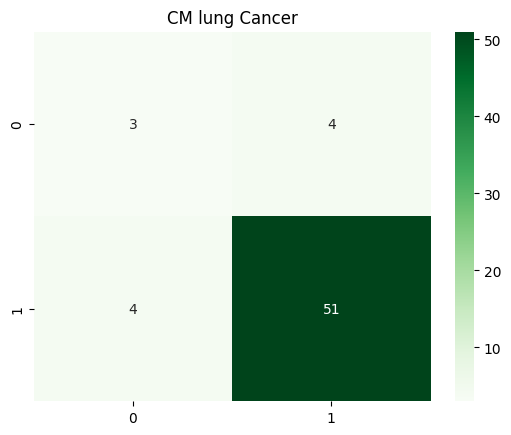

In [340]:
sns.heatmap(cm, annot=True, cmap="Greens")
plt.title("CM lung Cancer")
plt.show()

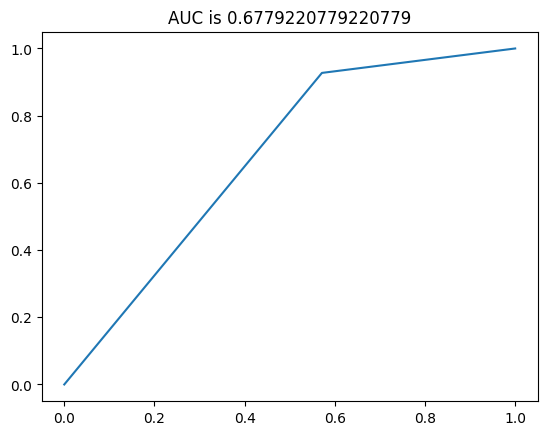

In [341]:
fpr, tpr, _ = roc_curve(Y_test, Y_pred)
auc = roc_auc_score(Y_test, Y_pred)
plt.plot(fpr,tpr)
plt.title(f"AUC is {auc}")
plt.show()